In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from keras.models import Sequential, Model
from keras.losses import MeanSquaredError
from keras.metrics import RootMeanSquaredError
from keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import tensorflow.keras.backend as K
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.layers import MultiHeadAttention
from tensorflow.keras.regularizers import l2
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, AveragePooling1D, LSTM, BatchNormalization, Attention, Dropout, Dense, GlobalAveragePooling1D, Embedding, Reshape, Concatenate

In [2]:
data = pd.read_csv("/Users/iraklisdimitriadis/Documents/Μαθήματα-Σημειώσεις Data Science/Dissertation/Processed Data/cleaned_data_csv.csv", index_col= "datetime", parse_dates= True)
data.head()

,Kwh,name,temp,feelslike,dew,humidity,precip,snow,snowdepth,windgust,windspeed,winddir,sealevelpressure,cloudcover,visibility,solarradiation,solarenergy,uvindex,conditions,icon
datetime,,,,,,,,,,,,,,,,,,,,
2022-01-01 00:00:00,0.0,"Kozani, Greece",6.0,4.4,2.0,75.51,0.0,0.0,0.0,19.8,7.6,240.0,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 01:00:00,0.0,"Kozani, Greece",6.0,5.0,2.0,75.51,0.0,0.0,0.0,19.8,5.4,298.1,1023.0,0.0,NaN,0.0,0.0,0.0,Clear,clear-night
2022-01-01 02:00:00,0.0,"Kozani, Greece",4.9,3.2,2.0,81.61,0.0,NaN,0.0,20.5,7.6,301.0,1022.4,40.9,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 03:00:00,0.0,"Kozani, Greece",4.0,4.0,1.0,80.80,0.0,NaN,0.0,20.5,3.6,294.8,1022.0,38.0,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night
2022-01-01 04:00:00,0.0,"Kozani, Greece",3.0,1.6,2.0,93.14,0.0,NaN,0.0,19.8,5.4,292.3,1021.0,41.7,NaN,0.0,0.0,0.0,Partially cloudy,partly-cloudy-night


In [3]:
df_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]
mean_13_00 = data[data.index.time == pd.Timestamp('13:00:00').time()]['solarradiation'].mean()

df_13_00, mean_13_00

(                        Kwh            name  temp  feelslike   dew  humidity  \
 datetime                                                                       
 2022-01-01 13:00:00  0.4263  Kozani, Greece  14.0       14.0   3.0     47.46   
 2022-01-02 13:00:00  0.4391  Kozani, Greece  14.0       14.0   1.0     41.15   
 2022-01-03 13:00:00  0.4421  Kozani, Greece  13.0       13.0   3.0     50.65   
 2022-01-04 13:00:00  0.4611  Kozani, Greece  11.0       11.0   0.0     46.61   
 2022-01-05 13:00:00  0.4397  Kozani, Greece  14.0       14.0   2.0     44.20   
 ...                     ...             ...   ...        ...   ...       ...   
 2024-06-30 13:00:00  0.6883  Kozani, Greece  31.0       29.1   7.0     22.30   
 2024-07-01 13:00:00  0.6906  Kozani, Greece  33.9       32.2  10.6     24.14   
 2024-07-02 13:00:00  0.4582  Kozani, Greece  31.0       29.5  10.0     27.32   
 2024-07-03 13:00:00  0.7472  Kozani, Greece  25.0       25.0   9.0     36.24   
 2024-07-04 13:00:00  0.6692

In [4]:
data['solarradiation'].fillna(mean_13_00, inplace=True)

In [5]:
kwh_data = data[['temp', 'humidity', 'windgust', 'winddir', 'cloudcover', 'solarradiation', 'conditions']]
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions
datetime,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,Clear
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,Clear
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,Partially cloudy
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,Partially cloudy
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,Partially cloudy
...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,Partially cloudy
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,"Rain, Partially cloudy"
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,"Rain, Partially cloudy"


In [6]:
kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])
kwh_data = kwh_data.drop('conditions', axis= 1)
kwh_data['hour'] = kwh_data.index.hour
kwh_data['day'] = kwh_data.index.day
kwh_data['month'] = kwh_data.index.month
kwh_data

/var/folders/gz/cwz0bhwd75x82b_jzt_7l1qw0000gn/T/ipykernel_3220/4253170597.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  kwh_data['conditions_int'] = LabelEncoder().fit_transform(data['conditions'])


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month
datetime,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0,0,1,1
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0,1,1,1
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2,2,1,1
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2,3,1,1
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2,4,1,1
...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7


In [7]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh
datetime,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0,0,1,1,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0,1,1,1,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2,2,1,1,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2,3,1,1,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2,4,1,1,0.0000
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7,0.0000


In [8]:
kwh_data = pd.concat([kwh_data, data['Kwh']], axis= 1)
kwh_data

,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh,Kwh
datetime,,,,,,,,,,,,
2022-01-01 00:00:00,6.0,75.51,19.8,240.0,0.0,0.0,0,0,1,1,0.0000,0.0000
2022-01-01 01:00:00,6.0,75.51,19.8,298.1,0.0,0.0,0,1,1,1,0.0000,0.0000
2022-01-01 02:00:00,4.9,81.61,20.5,301.0,40.9,0.0,2,2,1,1,0.0000,0.0000
2022-01-01 03:00:00,4.0,80.80,20.5,294.8,38.0,0.0,2,3,1,1,0.0000,0.0000
2022-01-01 04:00:00,3.0,93.14,19.8,292.3,41.7,0.0,2,4,1,1,0.0000,0.0000
...,...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,24.0,41.15,22.0,180.0,79.3,207.0,2,19,4,7,0.0592,0.0592
2024-07-04 20:00:00,23.0,40.87,22.0,172.8,81.7,103.0,5,20,4,7,0.0085,0.0085
2024-07-04 21:00:00,21.0,49.39,14.4,0.0,63.7,9.0,5,21,4,7,0.0000,0.0000


In [9]:
scaler = StandardScaler()
df_scaled_kwh = scaler.fit_transform(kwh_data.iloc[:, :11])
df_scaled_kwh = pd.DataFrame(df_scaled_kwh)
df_scaled_kwh.head(20)

,0,1,2,3,4,5,6,7,8,9,10
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
5,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890
6,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890
7,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890
8,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965
9,-0.844550,0.924518,0.745665,0.530576,0.058244,-0.580657,0.662831,-0.361218,-1.662386,-1.452052,-0.234996


In [10]:
df_scaled_kwh.index = data.index
df_scaled_kwh

,0,1,2,3,4,5,6,7,8,9,10
datetime,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890
...,...,...,...,...,...,...,...,...,...,...,...
2024-07-04 19:00:00,1.205675,-0.843987,0.638373,-0.278091,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121
2024-07-04 20:00:00,1.091774,-0.856388,0.638373,-0.331022,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731
2024-07-04 21:00:00,0.863971,-0.479036,-0.177047,-1.601364,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890


In [11]:
df_scaled_kwh = pd.concat([df_scaled_kwh, data["Kwh"]], axis=1)
df_scaled_kwh.columns = ["temp", "humidity", "windgust", "winddir",	"cloudcover", "solarradiation", "conditions_int", "hour", "day", "month", "Kwh Train", "Kwh Target"]
df_scaled_kwh.head(20)


,temp,humidity,windgust,winddir,cloudcover,solarradiation,conditions_int,hour,day,month,Kwh Train,Kwh Target
datetime,,,,,,,,,,,,
2022-01-01 00:00:00,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 01:00:00,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 02:00:00,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 03:00:00,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 04:00:00,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 05:00:00,-1.186254,1.457328,0.380872,0.574686,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 06:00:00,-1.072353,1.177858,0.520352,1.045183,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 07:00:00,-0.844550,0.677822,0.670561,0.898152,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890,0.0000
2022-01-01 08:00:00,-0.958452,0.918760,0.670561,0.898152,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965,0.0305


In [12]:
def reshape_dataframe_with_target(df, n=5):
    num_columns = len(df.columns) - 1  
    new_columns = [f"{col}{i+1}" for i in range(n) for col in df.columns if col != 'Kwh Target']
    
    reshaped_data = []

    for i in range(len(df) - n):
        new_row = []
        for j in range(n):
            new_row.extend(df.iloc[i + j][df.columns[:-1]].values)  
        new_row.append(df.iloc[i + n]['Kwh Target'])  
        reshaped_data.append(new_row)

    reshaped_df = pd.DataFrame(reshaped_data, columns=new_columns + ['Kwh Target'])
    
    return reshaped_df

reshaped_df = reshape_dataframe_with_target(df_scaled_kwh, n=5)
reshaped_df


,temp1,humidity1,windgust1,winddir1,cloudcover1,solarradiation1,conditions_int1,hour1,day1,month1,...,windgust5,winddir5,cloudcover5,solarradiation5,conditions_int5,hour5,day5,month5,Kwh Train5,Kwh Target
0,-0.844550,0.677822,0.402331,0.163000,-1.229211,-0.667640,-1.128321,-1.661400,-1.662386,-1.452052,...,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,-0.679890,0.0000
1,-0.844550,0.677822,0.402331,0.590124,-1.229211,-0.667640,-1.128321,-1.516935,-1.662386,-1.452052,...,0.380872,0.574686,-0.209547,-0.667640,0.662831,-0.939076,-1.662386,-1.452052,-0.679890,0.0000
2,-0.969842,0.947992,0.477435,0.611443,-0.176073,-0.667640,0.662831,-1.372470,-1.662386,-1.452052,...,0.520352,1.045183,-0.078226,-0.667640,0.662831,-0.794612,-1.662386,-1.452052,-0.679890,0.0000
3,-1.072353,0.912117,0.477435,0.565864,-0.250745,-0.667640,0.662831,-1.228006,-1.662386,-1.452052,...,0.670561,0.898152,0.416156,-0.667640,0.662831,-0.650147,-1.662386,-1.452052,-0.679890,0.0305
4,-1.186254,1.458657,0.402331,0.547485,-0.155474,-0.667640,0.662831,-1.083541,-1.662386,-1.452052,...,0.670561,0.898152,0.055669,-0.644949,0.662831,-0.505682,-1.662386,-1.452052,-0.542965,0.0991
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21973,1.433478,-1.346237,-0.219964,0.971668,-0.585484,0.228662,0.662831,0.361106,-1.322047,0.316003,...,1.249938,-0.351606,0.871915,1.121182,3.349560,0.938965,-1.322047,0.316003,0.351762,0.0592
21974,1.547379,-1.504795,0.209205,-1.380819,1.005811,3.333572,0.662831,0.505571,-1.322047,0.316003,...,0.638373,-0.278091,0.812692,0.115206,0.662831,1.083429,-1.322047,0.316003,-0.414121,0.0085
21975,1.319577,-1.265186,0.166288,-1.086758,1.142281,2.429706,-0.232745,0.650035,-1.322047,0.316003,...,0.638373,-0.331022,0.874490,-0.278108,3.349560,1.227894,-1.322047,0.316003,-0.641731,0.0000
21976,1.091774,-0.856388,0.327226,-0.498636,1.083058,0.448010,0.662831,0.794500,-1.322047,0.316003,...,-0.177047,-1.601364,0.411006,-0.633603,3.349560,1.372359,-1.322047,0.316003,-0.679890,0.0000


In [13]:
reshaped_df.iloc[0]

temp1             -0.844550
humidity1          0.677822
windgust1          0.402331
winddir1           0.163000
cloudcover1       -1.229211
solarradiation1   -0.667640
conditions_int1   -1.128321
hour1             -1.661400
day1              -1.662386
month1            -1.452052
Kwh Train1        -0.679890
temp2             -0.844550
humidity2          0.677822
windgust2          0.402331
winddir2           0.590124
cloudcover2       -1.229211
solarradiation2   -0.667640
conditions_int2   -1.128321
hour2             -1.516935
day2              -1.662386
month2            -1.452052
Kwh Train2        -0.679890
temp3             -0.969842
humidity3          0.947992
windgust3          0.477435
winddir3           0.611443
cloudcover3       -0.176073
solarradiation3   -0.667640
conditions_int3    0.662831
hour3             -1.372470
day3              -1.662386
month3            -1.452052
Kwh Train3        -0.679890
temp4             -1.072353
humidity4          0.912117
windgust4          0

In [14]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt



x = reshaped_df.drop(columns=['Kwh Target']).values  
y = reshaped_df['Kwh Target'].values  

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.1, shuffle= False)

x_val, x_test, y_val, y_test = train_test_split(x_test, y_test, test_size= 0.5, shuffle= False)

In [15]:
x_train.shape, y_train.shape, x_val.shape, y_val.shape, x_test.shape, y_test.shape

((19780, 55), (19780,), (1099, 55), (1099,), (1099, 55), (1099,))

In [16]:
early_stopping = EarlyStopping(monitor='val_loss', patience=25, restore_best_weights=True)
lr_scheduler = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6)

checkpoint_callback = ModelCheckpoint(
    filepath='D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras',
    monitor='val_loss',
    save_best_only=True, 
    mode='min',     
    save_weights_only=False,
    verbose=1 
)

In [17]:
x_train.shape[1]

55

In [18]:
input_shape = (x_train.shape[1],)
inputs = layers.Input(shape=input_shape)

x = layers.Dense(256, activation='relu')(inputs)
x = layers.Dropout(0.2)(x)

x = layers.Dense(132, activation='relu')(x)
x = layers.Reshape((132, 1))(x)  

attn_output = layers.MultiHeadAttention(num_heads=4, key_dim=16)(x, x) 

x = layers.Flatten()(attn_output)
x = layers.Dense(64, activation='relu')(x)
x = layers.Dense(32, activation='relu')(x)
x = layers.Dense(16, activation='relu')(x)

outputs = layers.Dense(1, activation='linear')(x)

model = Model(inputs=inputs, outputs=outputs)

model.compile(optimizer='adam', loss='mean_squared_error')

model.summary()


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 55)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │     14,336 │ input_layer[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 132)       │     33,924 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 132, 1)    │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 132, 1)    │        449 │ reshape[0][0],    │
│ (MultiHeadAttentio… │                   │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 132)       │          0 │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,512 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 32)        │      2,080 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 16)        │        528 │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         17 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 59,846 (233.77 KB)

 Trainable params: 59,846 (233.77 KB)

 Non-trainable params: 0 (0.00 B)

In [19]:
import time

start = time.time()
history = model.fit(x_train, y_train, 
            validation_data=(x_val, y_val), 
            epochs=100,
            batch_size=16,
            callbacks=[checkpoint_callback, lr_scheduler, early_stopping]
            )

end = time.time()

Epoch 1/100
1231/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0097
Epoch 1: val_loss improved from inf to 0.00538, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - loss: 0.0096 - val_loss: 0.0054 - learning_rate: 0.0010
Epoch 2/100
1229/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0037
Epoch 2: val_loss improved from 0.00538 to 0.00517, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0037 - val_loss: 0.0052 - learning_rate: 0.0010
Epoch 3/100
1231/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0034
Epoch 3: val_loss improved from 0.00517 to 0.00497, saving model to D:/Σπουδές/Μαθήματα-Σημειώσεις Data Science/Dissertation/Models.keras
1237/1237 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - loss: 0.0034 - val_loss: 0.0050 - learning_rate: 0.0010
Epoch 4/100
1236/1237 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0032
Epoch 

In [20]:
print(f"{round((end - start) / 60, 4)} mins")

6.8549 mins


In [21]:
y_pred = model.predict(x_test)

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step


In [22]:
y_pred_flat = y_pred.flatten()
y_test_flat = y_test.flatten()

results_df = pd.DataFrame({
    'Predicted': y_pred_flat,
    'True': y_test_flat
})

results_df['Predicted'] = round(results_df['Predicted'], 4)
results_df.head(20)

,Predicted,True
0,0.0010,0.0000
1,0.0128,0.0016
2,0.0286,0.0463
3,0.1881,0.1792
4,0.3102,0.4355
5,0.5031,0.5716
6,0.6218,0.5960
7,0.6274,0.6821
8,0.6456,0.7122
9,0.6204,0.6767


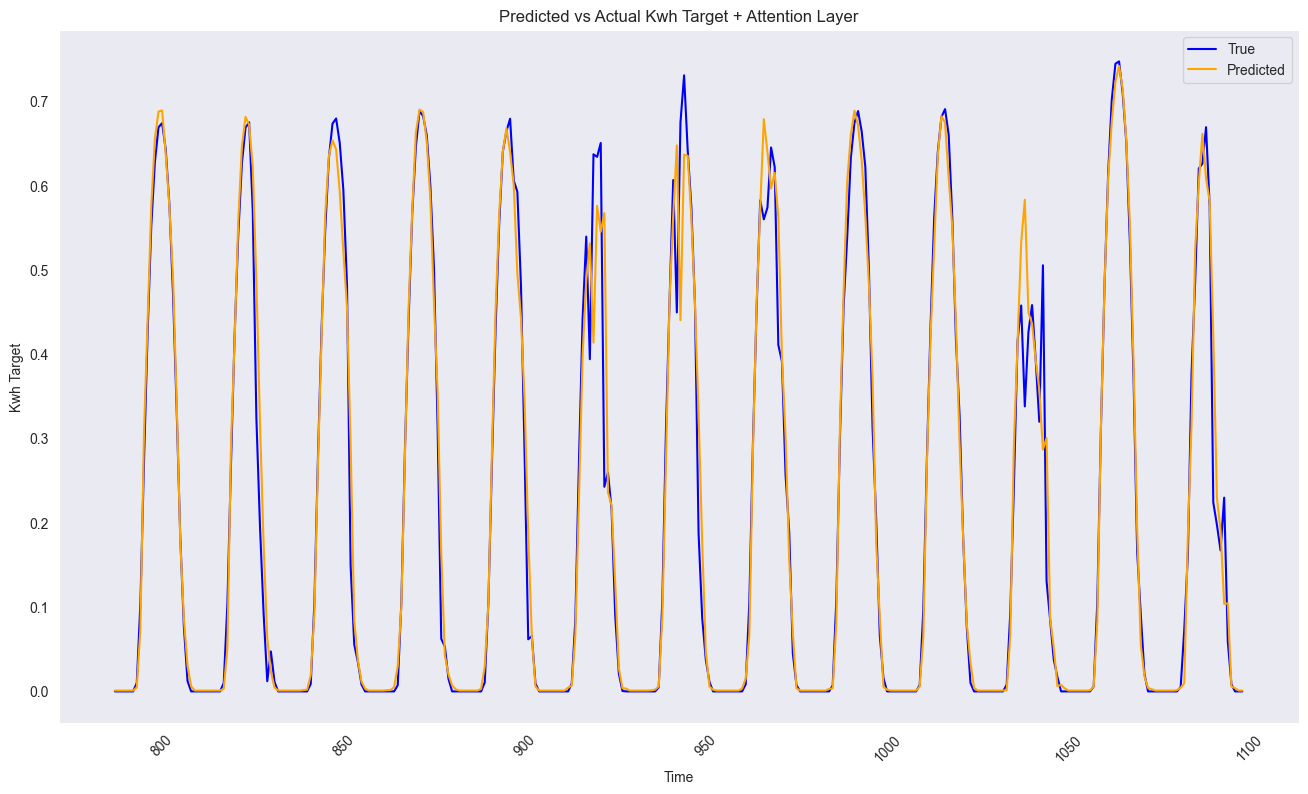

In [23]:
last_312_df = results_df.tail(312)


plt.figure(figsize=(16, 9))
sns.set_style('darkgrid')
sns.lineplot(x=last_312_df.index, y=last_312_df['True'], label='True', color='blue')
sns.lineplot(x=last_312_df.index, y=last_312_df['Predicted'], label='Predicted', color='orange')
plt.xlabel('Time')
plt.ylabel('Kwh Target')
plt.title('Predicted vs Actual Kwh Target + Attention Layer')
plt.legend()
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [24]:
r2_score(y_pred_flat, y_test_flat)

0.951233781117859

$
\hspace{4cm} \textbf{Simple Dense Model} \hspace{2.5cm} \textbf{Model with Dropout(0.2)} \hspace{2.5cm} \textbf{Model with Attention Layer} \\
Time Delay = 5 \rightarrow \hspace{2cm} 0.944224 \hspace{5cm} 0.9460512 \hspace{6cm} 0.9512337 \\
Time Delay = 8 \rightarrow \hspace{2cm} 0.936704 \hspace{5cm} 0.9483161 \hspace{6cm} 0.9465363\\ 
Time Delay = 12 \rightarrow \hspace{1.85cm} 0.949178 \hspace{5cm} 0.9504530 \hspace{6cm} 0.9505430 \\
Time Delay = 16 \rightarrow \hspace{1.85cm} 0.949806 \hspace{5cm} 0.9503922 \hspace{6cm} 0.9461176 \\
Time Delay = 24 \rightarrow \hspace{1.85cm} 0.946911 \hspace{5cm} 0.9418904 \hspace{6cm} 0.9402923
$

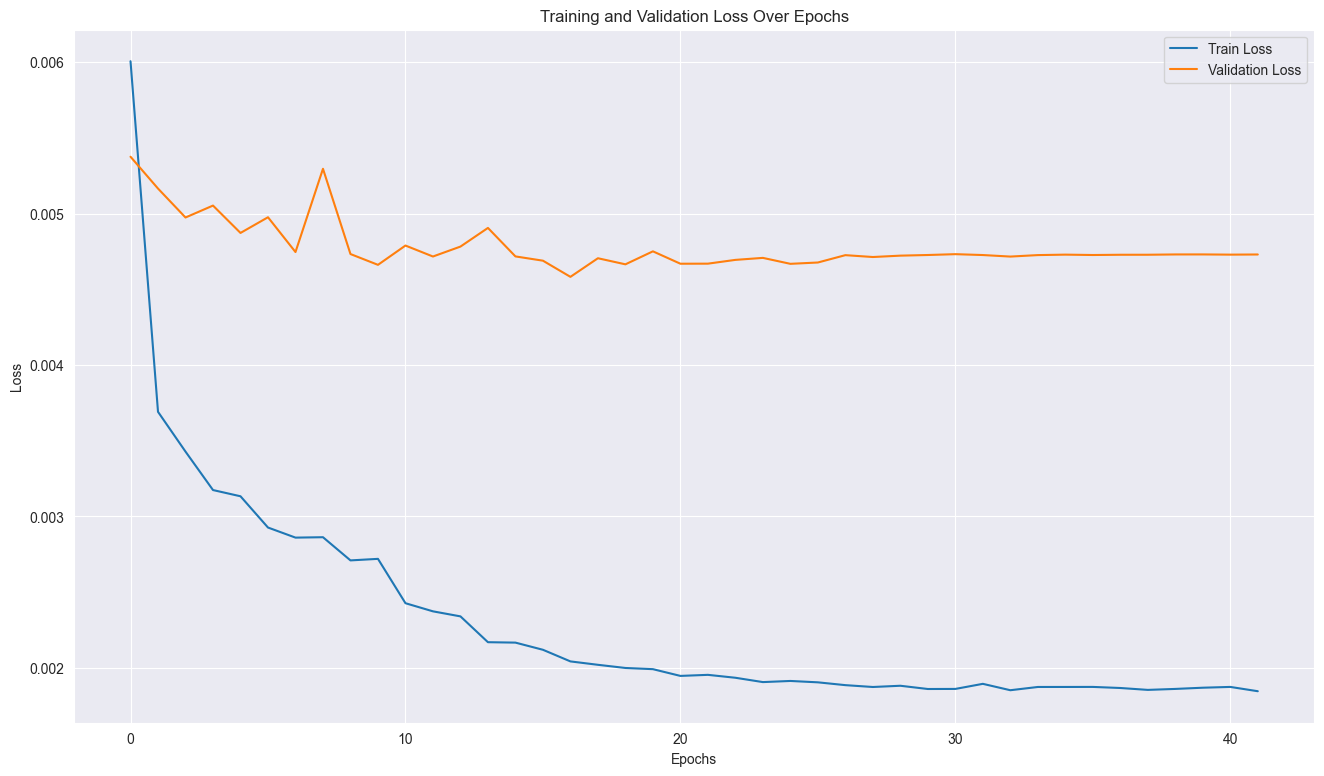

In [25]:
plt.figure(figsize = (16, 9))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss Over Epochs')
plt.legend()
plt.show()

<Axes: >

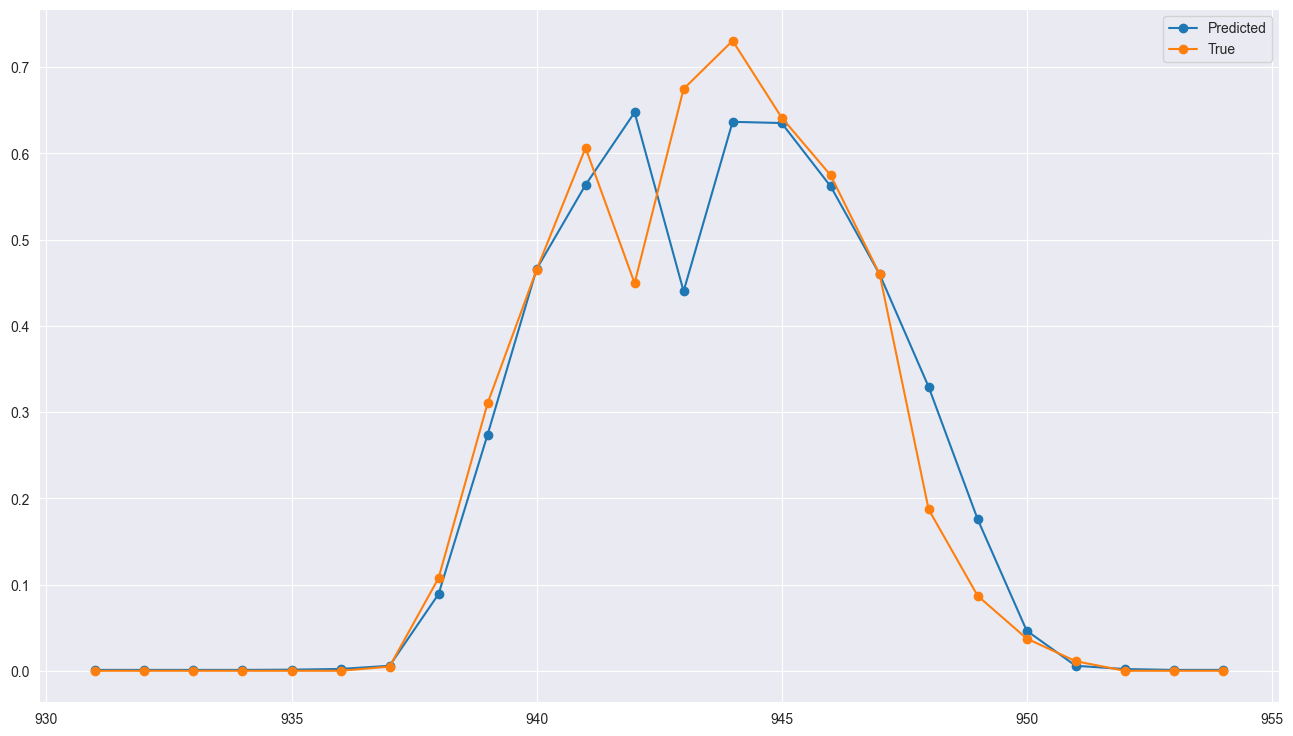

In [26]:
results_df[-168: - 144].plot(figsize=(16, 9), marker = 'o')

<Axes: >

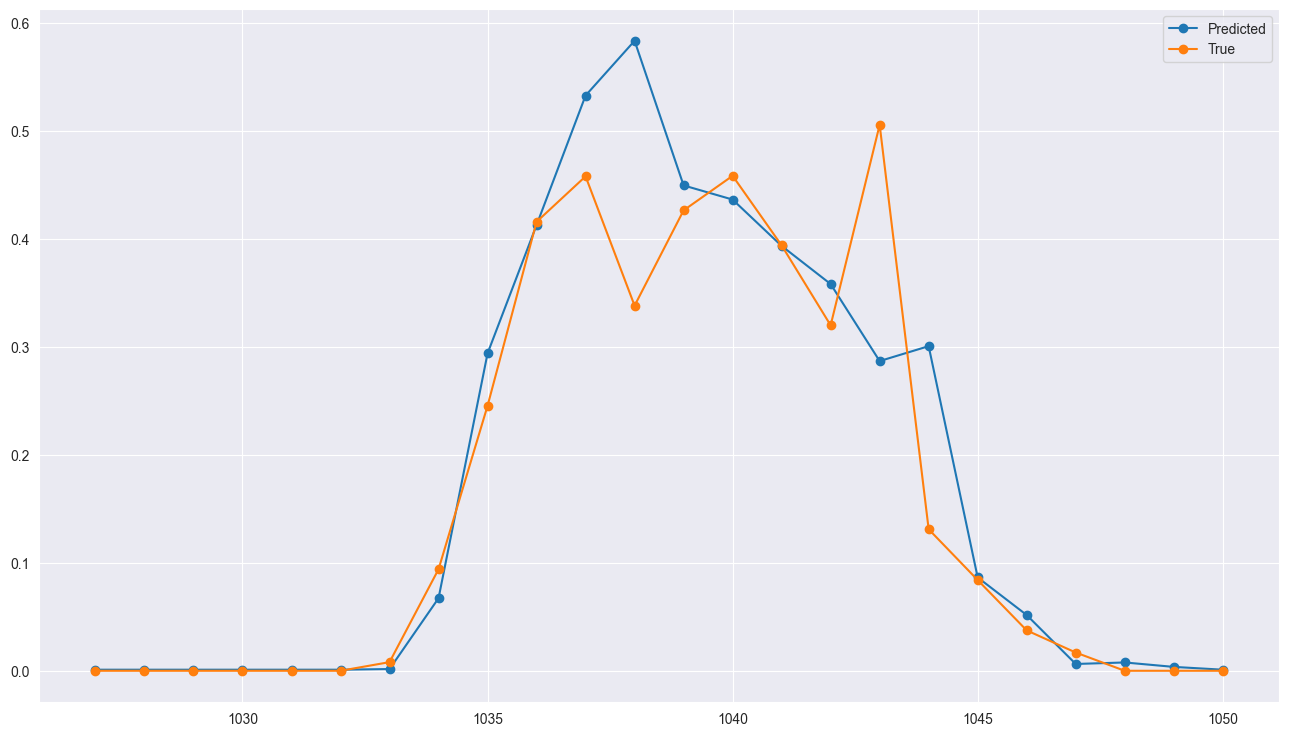

In [27]:
results_df[-72: -48].plot(figsize= (16, 9), marker = "o")

In [28]:
mean_squared_error(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.005628301319474255

In [29]:
r2_score(results_df[-168: - 144]['Predicted'], results_df[-168: - 144]['True'])

0.9109306671251944